# Forecasting one purchase: the newsvendor

A shop buys gift boxes once before next week's market. Unsold boxes have a
salvage value; unmet demand is lost. **How many should it buy?**

We use artificial historical demand to forecast next week's demand distribution,
choose its economically relevant quantile, and pass that target to Stockcast:

**past demand → forecast distribution → economic quantile → one order → outcome**

This example needs only NumPy, pandas, Matplotlib, and Stockcast.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stockcast import (
    InventoryStateDataFrame, SingleOrderPolicy, SimulationEngine,
    newsvendor_critical_fractile,
)
from stockcast.evaluation import validate_event_frame

## 1. Forecast next week's demand from history

Generate 40 comparable market weeks and reserve the next week for evaluation.
These are **uncensored demand observations**, not sales limited by available
stock. Our declared artificial process is stationary: independent Poisson
weekly demand with mean 40, no trend, seasonality, or changing covariates.

The forecaster does not receive that generating mean. Instead, its fitted
**empirical predictive distribution** gives each historical observation equal
weight. This is a simple nonparametric baseline assuming future weeks resemble
past weeks. It estimates uncertainty from history; it cannot extrapolate beyond
the observed range. A richer external forecaster can replace this step.

In [3]:
seed = 42
rng = np.random.default_rng(seed)
series = pd.DataFrame({
    "date": pd.date_range("2025-01-06", periods=41, freq="W-MON"),
    "demand": rng.poisson(lam=40, size=41),
})
history = series.iloc[:-1].copy()
held_out = series.iloc[-1:].copy()  # Never used to fit or choose the order.
origin = history.date.iloc[-1]
season_date = origin + pd.offsets.Week(weekday=0)

# Fitted external forecast: one equally weighted scenario per past week.
forecast_samples = history.demand.to_numpy(copy=True)
forecast_mean = forecast_samples.mean()
assert history.date.max() < held_out.date.min()
assert season_date == held_out.date.iloc[0]
history.tail()

,date,demand
35,2025-09-08,43
36,2025-09-15,46
37,2025-09-22,44
38,2025-09-29,33
39,2025-10-06,32


## 2. Let the economics choose the quantile

Each box sells for **10**, costs **4**, and has terminal salvage value **2**.
There is no opening stock, backlog, capacity limit, extra holding/shortage cost,
or purchase during the selling week. Delivery is immediate before demand.

The underage cost is `10−4=6`; the overage cost is `4−2=2`.
The critical probability is therefore `6/(6+2)=0.75`. We buy the smallest
integer quantity whose forecast cumulative probability reaches 0.75—not the
mean and not an arbitrary 95% target. This probability is not a guaranteed
achieved fill rate.

In [4]:
price, cost, salvage = 10.0, 4.0, 2.0
alpha = newsvendor_critical_fractile(
    selling_price=price, purchase_cost=cost, salvage_value=salvage,
)
quantity = int(np.quantile(forecast_samples, alpha, method="inverted_cdf"))

# Independently check expected profit under the fitted forecast distribution.
candidates = np.arange(forecast_samples.max() + 11)
scenario_profit = (
    price * np.minimum(candidates[:, None], forecast_samples)
    - cost * candidates[:, None]
    + salvage * np.maximum(candidates[:, None] - forecast_samples, 0)
)
forecast_profit = scenario_profit.mean(axis=1)
assert np.isclose(forecast_profit[quantity], forecast_profit.max())
assert np.mean(forecast_samples < quantity) < alpha
assert np.mean(forecast_samples <= quantity) >= alpha
pd.DataFrame([{
    "forecast_mean": forecast_mean, "critical_probability": alpha,
    "purchase_quantity": quantity,
    "forecast_expected_profit": forecast_profit[quantity],
}]).round(2)

,forecast_mean,critical_probability,purchase_quantity,forecast_expected_profit
0,39.78,0.75,44,226.2


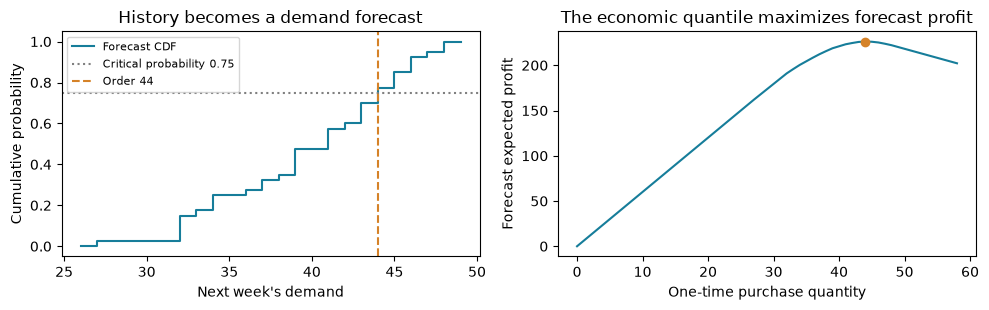

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
values, counts = np.unique(forecast_samples, return_counts=True)
cdf_x = np.r_[values[0] - 1, values, values[-1] + 1]
cdf_y = np.r_[0, counts.cumsum() / len(forecast_samples), 1]
axes[0].step(cdf_x, cdf_y, where="post", color="#167d9a", label="Forecast CDF")
axes[0].axhline(alpha, color="0.5", linestyle=":", label=f"Critical probability {alpha:.2f}")
axes[0].axvline(quantity, color="#d58228", linestyle="--", label=f"Order {quantity}")
axes[0].set(xlabel="Next week's demand", ylabel="Cumulative probability",
            title="History becomes a demand forecast")
axes[0].legend(fontsize=8)
axes[1].plot(candidates, forecast_profit, color="#167d9a")
axes[1].scatter([quantity], [forecast_profit[quantity]], color="#d58228", zorder=3)
axes[1].set(xlabel="One-time purchase quantity", ylabel="Forecast expected profit",
            title="The economic quantile maximizes forecast profit")
fig.tight_layout()
plt.show()

## 3. Define the newsvendor in Stockcast

`SingleOrderPolicy` is the one-purchase policy; `selling_horizon=1` means one
weekly demand observation covers this selling season. It creates its one-time
schedule internally. With `lead_time=0`, the order arrives before that demand.

The forecast handoff is a dated, precomputed target with its probability and
source. `fit()` binds that external target to the policy; it does not train the
forecaster. With zero opening stock and pipeline, the target is the purchase
quantity.

In [6]:
target = pd.DataFrame({
    "unique_id": ["gift_box"],
    "season_q75": [quantity],
    "season_end": [season_date],
})
policy = SingleOrderPolicy(
    lead_time=0, selling_horizon=1,
    service_level=alpha, allow_backorders=False,
).fit(
    target, forecast_origin=origin, forecast_frequency="W-MON",
    target_column="season_q75", target_probability=alpha,
    target_end_date_column="season_end", target_source="external_direct",
)
opening = InventoryStateDataFrame(
    ["gift_box"], max_lead_time=0, allow_backorders=False,
).initialize_zero(start_date=origin)
target

,unique_id,season_q75,season_end
0,gift_box,44,2025-10-13


## 4. Reveal the held-out week and account for the result

Only now use the next week's actual demand. Profit is calculated explicitly
from validated event flows, including terminal salvage. Stockcast retains
leftover inventory; this calculation does not post an automatic liquidation.

In [7]:
actual = int(held_out.demand.iloc[0])
demand = pd.DataFrame({
    "unique_id": ["gift_box"], "period": [0],
    "date": [season_date], "y": [actual],
})
result = SimulationEngine().run(
    policy, demand, opening, n_periods=1,
    period_frequency="W-MON", warmup_periods=0, scoring_periods=1,
    settlement_periods=0, order_during_settlement=False,
    demand_source_name="synthetic_held_out_market_week", random_seed=seed,
)
events = validate_event_frame(result.to_event_frame())
row = events.iloc[0]
realized_profit = (
    price * row.fulfilled_units - cost * row.order_quantity
    + salvage * row.ending_on_hand
)
assert events.order_event_count.sum() == 1
assert row.order_quantity == row.received_units == quantity
assert row.fulfilled_units == min(quantity, actual)
assert row.ending_on_hand == max(quantity - actual, 0)
assert row.lost_sales_units == max(actual - quantity, 0)
assert row.on_order_end == 0
pd.DataFrame([{
    "ordered": quantity, "actual_demand": actual,
    "sold": row.fulfilled_units, "leftover": row.ending_on_hand,
    "lost_sales": row.lost_sales_units, "realized_profit": realized_profit,
}])

,ordered,actual_demand,sold,leftover,lost_sales,realized_profit
0,44,39,39.0,5.0,0.0,224.0


We have defined a complete newsvendor: a **forecast distribution**, **linear
unit economics**, **one pre-demand purchase**, and **one selling season**.
The quantity maximizes expected profit under the fitted empirical forecast;
one held-out outcome does not establish calibration or real-world superiority.

To use your own forecasting model, replace `forecast_samples` with its
predictive draws—or supply its precomputed quantile at `alpha`—while preserving
the information cutoff and season coverage. A point forecast alone is not a
predictive distribution. For a season spread over daily rows, forecast the
**total season demand**; never sum daily marginal quantiles.

References: [economic newsvendor formula and assumptions (Stockpyl)](https://stockpyl.readthedocs.io/en/latest/_modules/stockpyl/newsvendor.html)
and [empirical inverse-CDF quantiles (NumPy)](https://numpy.org/doc/stable/reference/generated/numpy.quantile.html).
See [04 — Forecast integration](04_forecast_to_inventory_integration.ipynb)
for the recurring-replenishment workflow.